## Process output of simulations

In [1]:
import os
import glob
import gzip
import math
import random
import pickle

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.colors import LogNorm
import shapely.wkt as wkt
from shapely.geometry import Point, LineString, box
from shapely.ops import nearest_points
import lxml.etree as ET
import tqdm
import wandb
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset, Subset
import torch_geometric
from torch_geometric.data import Data, Batch
from torch_geometric.transforms import LineGraph
import processing_io as pio
import re 

districts = gpd.read_file("../../../../data/visualisation/districts_paris.geojson")

# Parameters to adapt
districts_of_policy_implementation = [5, 6, 7]
is_for_1pm = True
plot_in_percentage = True

string_is_for_1pm = "pop_1pm" if is_for_1pm else "pop_1pct"
string_district_of_interest = "_".join([str(d) for d in districts_of_policy_implementation])

path = "../../../../data/" +  string_is_for_1pm + "_simulations/"
basecase_subdir = pio.get_subdirs(path + string_is_for_1pm + "_basecase/")
comparison_subdir = pio.get_subdirs(path + string_is_for_1pm + "_policy_in_zone_2")

result_path_basecase_mean = "results/" + string_is_for_1pm + "_basecase_average_output_links.geojson"
result_path_comparison_mean = "results/gdf_" + string_is_for_1pm + "_policy_in_" + string_district_of_interest + ".geojson"
result_path_difference = "results/gdf_" + string_is_for_1pm + "_difference.geojson"

compute_comparison_with_basecase = False

In [2]:
random_seed_2_df_basecase_output_links = pio.create_dic_seed_2_output_links(subdir=basecase_subdir)
random_seed_2_df_basecase_eqasim_trips = pio.create_dic_seed_2_eqasim_trips_given_eqasim_trips(subdir=basecase_subdir)
basecase_output_links_gdfs = list(random_seed_2_df_basecase_output_links.values())
gdf_basecase_mean = pio.compute_average_or_median_geodataframe(geodataframes=basecase_output_links_gdfs, column_name="vol_car", is_mean=True)
gdf_basecase_mean = gdf_basecase_mean.rename(columns={"osm:way:highway": "highway"})
gdf_basecase_mean.to_file(result_path_basecase_mean, driver='GeoJSON')

In [3]:
# Calculate average travel time, routed distance, and trip count per mode across all seeds
def calculate_avg_mode_stats(single_mode_stats_list:list):
    mode_stats_list = []
    trip_count_list = []

    for df in single_mode_stats_list:
        mode_stats = df.groupby('mode').agg({
            'travel_time': 'sum',
            'routed_distance': 'sum'
        }).reset_index()
        mode_stats_list.append(mode_stats)

        trip_count = df.groupby('mode').size().reset_index(name='trip_count')
        trip_count_list.append(trip_count)

    # Concatenate all mode_stats and trip_count dataframes
    all_mode_stats = pd.concat(mode_stats_list, ignore_index=True)
    all_trip_counts = pd.concat(trip_count_list, ignore_index=True)

    # Calculate the average across all seeds
    average_mode_stats = all_mode_stats.groupby('mode').agg({
        'travel_time': 'mean',
        'routed_distance': 'mean'
    }).reset_index()
    average_mode_stats.columns = ['mode', 'avg_total_travel_time', 'avg_total_routed_distance']

    average_trip_count = all_trip_counts.groupby('mode').agg({
        'trip_count': 'mean'
    }).reset_index()
    average_trip_count.columns = ['mode', 'avg_trip_count']

    # Merge average trip count with average mode stats
    df_average_mode_stats = pd.merge(average_mode_stats, average_trip_count, on='mode', how='left')
    return df_average_mode_stats

df_average_mode_stats = calculate_avg_mode_stats(random_seed_2_df_basecase_eqasim_trips.values())
df_average_mode_stats.to_csv("results/pop_1pm_basecase_average_mode_stats.csv", index=False)

In [4]:
df_average_mode_stats.head()

,mode,avg_total_travel_time,avg_total_routed_distance,avg_trip_count
0,bike,4.638402e+05,1.438513e+06,390.803922
1,car,3.529376e+06,1.813432e+07,3750.470588
2,car_passenger,3.968791e+05,4.106681e+06,938.000000
3,outside,2.174118e+03,2.915092e+06,2756.235294
4,pt,6.518869e+06,2.224094e+07,4067.921569


In [5]:
if compute_comparison_with_basecase:
    random_seed_2_df_comparison = pio.create_dic_seed_2_output_links(subdir = comparison_subdir)
    geodataframes_comparison = list(random_seed_2_df_comparison.values())
    gdf_comparison_mean = pio.compute_average_or_median_geodataframe(geodataframes=geodataframes_comparison, column_name="vol_car", is_mean=True)
    gdf_comparison_mean_extended = pio.extend_geodataframe(gdf_base = gdf_basecase_mean, gdf_to_extend=gdf_comparison_mean, column_to_extend='highway', new_column_name='highway')
    gdf_basecase_without_unnecessary_columns = pio.remove_columns(gdf_with_correct_columns=gdf_comparison_mean_extended, gdf_to_be_adapted=gdf_basecase_mean)
    gdf_basecase_difference = pio.compute_difference_geodataframe(gdf_to_substract_from=gdf_comparison_mean_extended, gdf_to_substract=gdf_basecase_without_unnecessary_columns, column_name= 'vol_car')
    gdf_comparison_mean_extended.to_file(result_path_comparison_mean, driver='GeoJSON')
    gdf_basecase_difference.to_file(result_path_difference, driver='GeoJSON')

In [6]:
def calculate_edge_variance_metrics(simulation_gdfs, mean_gdf):
    edge_volumes = {}
    
    # Collect volumes for each edge across all simulations
    for df in simulation_gdfs:
        for idx, row in df.iterrows():
            link = row['link']
            volume = row['vol_car']
            if link not in edge_volumes:
                edge_volumes[link] = []
            edge_volumes[link].append(volume)
    
    # Calculate various variance metrics for each edge
    variances = {}
    cvs = {}  # Coefficient of Variation
    normalized_vars = {}  # Normalized Variance
    
    for link, volumes in edge_volumes.items():
        volumes_array = np.array(volumes)
        mean_vol = np.mean(volumes_array)
        var = np.var(volumes_array)
        std = np.std(volumes_array)
        
        variances[link] = var
        # CV = (standard deviation / mean) * 100%
        cvs[link] = (std / mean_vol * 100) if mean_vol != 0 else 0
        # Normalized variance = variance / mean^2
        normalized_vars[link] = (var / (mean_vol ** 2)) if mean_vol != 0 else 0
    
    # Add metrics to the mean_gdf
    mean_gdf['variance'] = mean_gdf['link'].map(variances)
    mean_gdf['cv_percent'] = mean_gdf['link'].map(cvs)  # Coefficient of Variation as percentage
    mean_gdf['normalized_variance'] = mean_gdf['link'].map(normalized_vars)
    
    return mean_gdf

# Apply the function to add variance metrics
gdf_basecase_mean = calculate_edge_variance_metrics(basecase_output_links_gdfs, gdf_basecase_mean)

In [7]:
# Compute the mean coefficient of variation over all edges
mean_cv_percent = gdf_basecase_mean['cv_percent'].mean()
print(f"\nMean Coefficient of Variation (CV) over all edges: {mean_cv_percent:.2f}%")

# Compute the mean car volume over all edges
mean_car_volume = gdf_basecase_mean['vol_car'].mean()
print(f"\nMean Car Volume over all edges: {mean_car_volume:.2f}")


# Investigate the coefficient of variation for different types of "highway"
highway_types = ['primary', 'secondary', 'tertiary', 'residential', 'trunk', 'living_street']
highway_cv_means = {}
highway_vol_means = {}

for highway in highway_types:
    highway_gdf = gdf_basecase_mean[gdf_basecase_mean['highway'] == highway]
    mean_cv = highway_gdf['cv_percent'].mean()
    highway_cv_means[highway] = mean_cv
    print(f"Mean Coefficient of Variation (CV) for {highway} roads: {mean_cv:.2f}%")
    
    mean_vol = highway_gdf['vol_car'].mean()
    highway_vol_means[highway] = mean_vol
    print(f"Mean Car Volume for {highway} roads: {mean_vol:.2f}")



Mean Coefficient of Variation (CV) over all edges: 49.11%

Mean Car Volume over all edges: 5.90
Mean Coefficient of Variation (CV) for primary roads: 31.34%
Mean Car Volume for primary roads: 13.59
Mean Coefficient of Variation (CV) for secondary roads: 46.98%
Mean Car Volume for secondary roads: 6.36
Mean Coefficient of Variation (CV) for tertiary roads: 46.10%
Mean Car Volume for tertiary roads: 4.57
Mean Coefficient of Variation (CV) for residential roads: 69.44%
Mean Car Volume for residential roads: 1.64
Mean Coefficient of Variation (CV) for trunk roads: 2.79%
Mean Car Volume for trunk roads: 111.74
Mean Coefficient of Variation (CV) for living_street roads: 90.09%
Mean Car Volume for living_street roads: 0.50


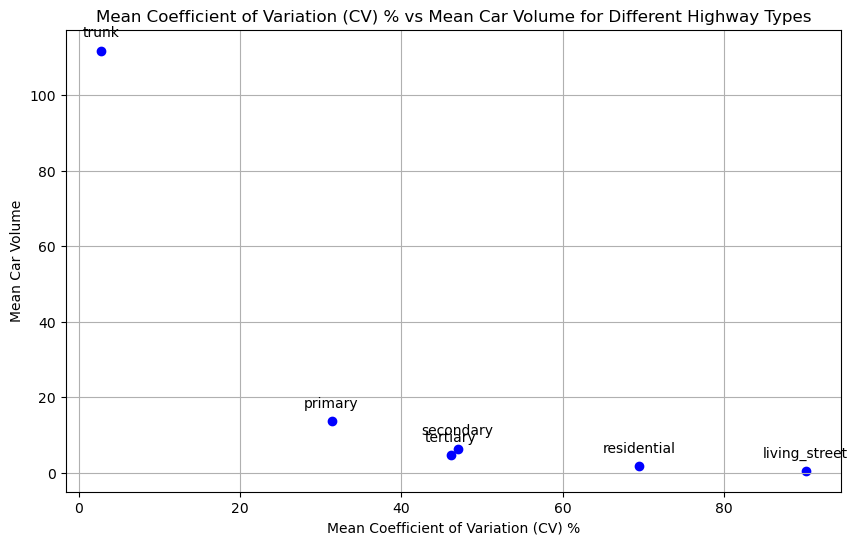

In [8]:

# Create a scatter plot with switched axes
plt.figure(figsize=(10, 6))
plt.scatter(list(highway_cv_means.values()), list(highway_vol_means.values()), color='blue')

# Add labels and title with switched axes
plt.xlabel('Mean Coefficient of Variation (CV) %')
plt.ylabel('Mean Car Volume')
plt.title('Mean Coefficient of Variation (CV) % vs Mean Car Volume for Different Highway Types')

# Add annotations for each highway type with switched axes
for highway, cv in highway_cv_means.items():
    vol = highway_vol_means[highway]
    plt.annotate(highway, (cv, vol), textcoords="offset points", xytext=(0,10), ha='center')

# Show the plot
plt.grid(True)
plt.show()